#  процесс работы

Здесь собрана история всех попыток, ошибок и переделок, через которые прошёл проект, прежде чем получилась финальная версия.

Для воспроизводимого результата см. `Lab3_final.ipynb`.

## 1. Установка зависимостей и подключение Drive

In [ ]:
!pip install -q torch_geometric

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 63.7/63.7 kB 3.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.3/1.3 MB 35.1 MB/s eta 0:00:00


In [ ]:
!pip install -q plyfile open3d

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 43.3/43.3 kB 2.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 447.7/447.7 MB 3.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 7.2/7.2 MB 45.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 139.8/139.8 kB 11.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.2/2.2 MB 47.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 4.9/4.9 MB 60.7 MB/s eta 0:00:00


In [ ]:

from google.colab import drive
drive.mount('/content/drive')


import os, sys, json, glob, random, time
from pathlib import Path
from collections import Counter, defaultdict

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

import torch
print("Torch:", torch.__version__, "| CUDA:", torch.cuda.is_available())
if torch.cuda.is_available():
    print("GPU:", torch.cuda.get_device_name(0))

Mounted at /content/drive
Torch: 2.11.0+cu128 | CUDA: True
GPU: Tesla T4


## 2. Кэширование PLY в .npz

Чтение PLY с Google Drive занимает ~10 секунд на файл, для 711 файлов это около 2 часов. Поэтому все облака один раз конвертируются в компактный формат `.npz` (только координаты и метки) и кэшируются на Drive.

Первоначально была ошибка с именами файлов — `np.savez_compressed` сам добавлял `.npz` к расширению, и в итоге сохранялись файлы вида `xxx.npz.tmp.npz`. Ниже идёт исправляющая ячейка с переименованием.

In [ ]:
from pathlib import Path
import numpy as np
from tqdm.auto import tqdm

CACHE_ROOT = Path('/content/drive/MyDrive/IS_project/cache_npz')

bad = sorted(CACHE_ROOT.rglob('*.npz.tmp.npz'))
print(f"Files with wrong name: {len(bad)}")

renamed = 0
collisions = 0
for p in tqdm(bad, desc='Renaming'):
    correct = p.with_name(p.name.replace('.npz.tmp.npz', '.npz'))
    if correct.exists():
        collisions += 1
        p.unlink()
    else:
        p.rename(correct)
        renamed += 1

print(f"Renamed: {renamed}, removed duplicates: {collisions}")

all_npz = sorted(CACHE_ROOT.rglob('*.npz'))
print(f"\nTotal .npz now: {len(all_npz)}")

ok, fail = 0, []
for p in tqdm(all_npz[:30], desc='Sanity check'):
    try:
        d = np.load(p)
        assert 'xyz' in d.files and 'label' in d.files
        assert d['xyz'].shape[1] == 3
        assert d['xyz'].shape[0] == d['label'].shape[0]
        ok += 1
    except Exception as e:
        fail.append((p.name, str(e)))

print(f"\nSanity: {ok}/30 ok, fails: {len(fail)}")
for n, e in fail[:5]:
    print(" ", n, '->', e)

if all_npz:
    d = np.load(all_npz[0])
    print(f"\nSample {all_npz[0].name}:")
    print(f"  xyz: shape={d['xyz'].shape} dtype={d['xyz'].dtype}")
    print(f"  label: shape={d['label'].shape} dtype={d['label'].dtype}")
    print(f"  unique labels: {np.unique(d['label']).tolist()}")

Files with wrong name: 0


Renaming: 0it [00:00, ?it/s]

Renamed: 0, removed duplicates: 0

Total .npz now: 711


Sanity check:   0%|          | 0/30 [00:00<?, ?it/s]


Sanity: 30/30 ok, fails: 0

Sample scan_circle_0001_factory_room_1_lidar_station_1.npz:
  xyz: shape=(500000, 3) dtype=float32
  label: shape=(500000,) dtype=int16
  unique labels: [1, 3, 4, 5, 6]


## 3. Проверка кэша и подсчёт распределения по сценам

После переименования кэш состоит из 711 файлов .npz. Все 8 сцен на месте.

In [ ]:
from pathlib import Path
import numpy as np
from tqdm.auto import tqdm

CACHE_ROOT = Path('/content/drive/MyDrive/IS_project/cache_npz')
all_npz = sorted(CACHE_ROOT.rglob('*.npz'))
print(f"Cached files on Drive: {len(all_npz)} / 711")

scenes = {}
for p in all_npz:
    s = p.relative_to(CACHE_ROOT).parts[0]
    scenes[s] = scenes.get(s, 0) + 1
print("\nFiles per scene:")
for s, n in sorted(scenes.items()):
    print(f"  {s:12s} {n}")

Cached files on Drive: 711 / 711

Files per scene:
  boliler      121
  control      63
  electrical   60
  laboratory   109
  maintenance  33
  office       111
  refinery     85
  storage      129


## 4. Исследовательский анализ данных (EDA)

Подсчёт полного распределения классов по всему датасету и по каждой сцене, веса классов для CrossEntropyLoss, сохранение конфигов и графиков EDA.

In [ ]:
import os, json, glob, random
from pathlib import Path
from collections import Counter
import numpy as np
import pandas as pd
from tqdm.auto import tqdm

DATA_ROOT = Path('/content/drive/MyDrive/IS')
PROJECT_ROOT = Path('/content/drive/MyDrive/IS_project')
CACHE_ROOT = PROJECT_ROOT / 'cache_npz'

CLASS_NAMES = [
    'unknown','pipe','wire','wall','floor','ceiling','machine','desk','rack',
    'boiler','conveyor','structure','infrastructure','roof','window','door',
    'gate','terrain','facade'
]
NUM_CLASSES = len(CLASS_NAMES)

all_npz = sorted(CACHE_ROOT.rglob('*.npz'))
print(f"Files: {len(all_npz)}")

global_counts = Counter()
scene_counts = {}
file_meta = []

for p in tqdm(all_npz, desc='Scanning labels'):
    d = np.load(p)
    lab = d['label']
    n = len(lab)
    scene = p.relative_to(CACHE_ROOT).parts[0]
    uniq, cnt = np.unique(lab, return_counts=True)
    for u, c in zip(uniq, cnt):
        global_counts[int(u)] += int(c)
        scene_counts.setdefault(scene, Counter())[int(u)] += int(c)
    file_meta.append({'cache': str(p), 'scene': scene, 'n_points': int(n)})

total = sum(global_counts.values())
print(f"\nTotal points: {total:,}")

rows = []
for c in range(NUM_CLASSES):
    cnt = global_counts.get(c, 0)
    rows.append({'class_id': c, 'class_name': CLASS_NAMES[c],
                 'points': cnt, 'share_%': round(100*cnt/total, 4) if total else 0})
df_full = pd.DataFrame(rows).sort_values('points', ascending=False)
print("\nFull class distribution:")
print(df_full.to_string(index=False))

df_full.to_csv(PROJECT_ROOT / 'results' / 'full_class_distribution.csv', index=False)
pd.DataFrame(file_meta).to_csv(PROJECT_ROOT / 'results' / 'file_manifest.csv', index=False)

scene_rows = []
for s, cnt in sorted(scene_counts.items()):
    row = {'scene': s, 'n_files': sum(1 for m in file_meta if m['scene']==s),
           'total_pts': sum(cnt.values())}
    for c in range(NUM_CLASSES):
        if cnt.get(c, 0) > 0:
            row[CLASS_NAMES[c]] = cnt[c]
    scene_rows.append(row)
df_scene = pd.DataFrame(scene_rows).fillna(0)
print("\nClass points per scene:")
print(df_scene.to_string(index=False))
df_scene.to_csv(PROJECT_ROOT / 'results' / 'scene_class_distribution.csv', index=False)

Files: 711


Scanning labels:   0%|          | 0/711 [00:00<?, ?it/s]


Total points: 353,117,237

Full class distribution:
 class_id     class_name    points  share_%
        5        ceiling 111253009  31.5060
        4          floor  85851446  24.3124
        3           wall  44959869  12.7323
       11      structure  25127404   7.1159
        8           rack  19708998   5.5814
        7           desk  17581892   4.9791
        6        machine  16899028   4.7857
        1           pipe  16719082   4.7347
        0        unknown   8771528   2.4840
        9         boiler   4456084   1.2619
       12 infrastructure   1458073   0.4129
        2           wire    330824   0.0937
       10       conveyor         0   0.0000
       13           roof         0   0.0000
       14         window         0   0.0000
       15           door         0   0.0000
       16           gate         0   0.0000
       17        terrain         0   0.0000
       18         facade         0   0.0000

Class points per scene:
      scene  n_files  total_pts   unknown 

Active classes: 12
  new= 0  old= 0  unknown            8,771,528  (2.484%)
  new= 1  old= 1  pipe              16,719,082  (4.735%)
  new= 2  old= 2  wire                 330,824  (0.094%)
  new= 3  old= 3  wall              44,959,869  (12.732%)
  new= 4  old= 4  floor             85,851,446  (24.312%)
  new= 5  old= 5  ceiling          111,253,009  (31.506%)
  new= 6  old= 6  machine           16,899,028  (4.786%)
  new= 7  old= 7  desk              17,581,892  (4.979%)
  new= 8  old= 8  rack              19,708,998  (5.581%)
  new= 9  old= 9  boiler             4,456,084  (1.262%)
  new=10  old=11  structure         25,127,404  (7.116%)
  new=11  old=12  infrastructure     1,458,073  (0.413%)

Class weights (mean=1):
  unknown         1.191
  pipe            0.801
  wire            2.521
  wall            0.380
  floor           0.224
  ceiling         0.181
  machine         0.796
  desk            0.774
  rack            0.715
  boiler          1.627
  structure       0.599
  inf

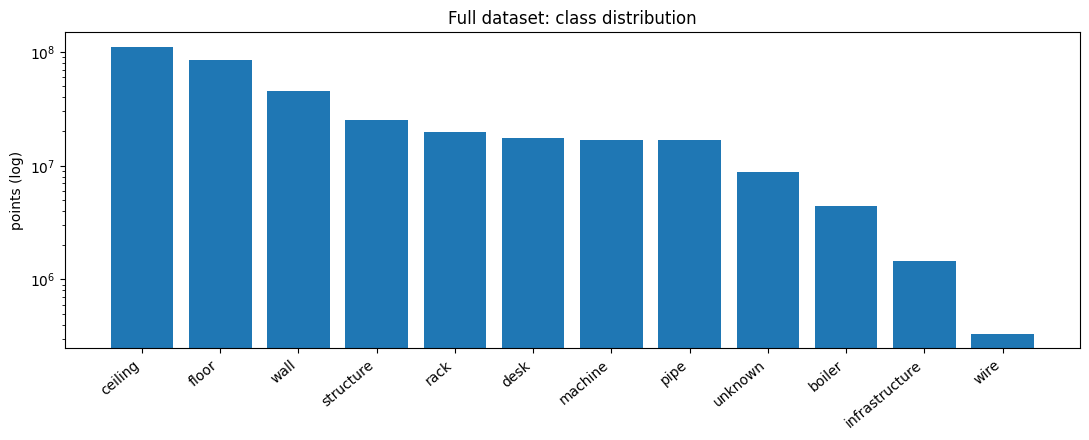

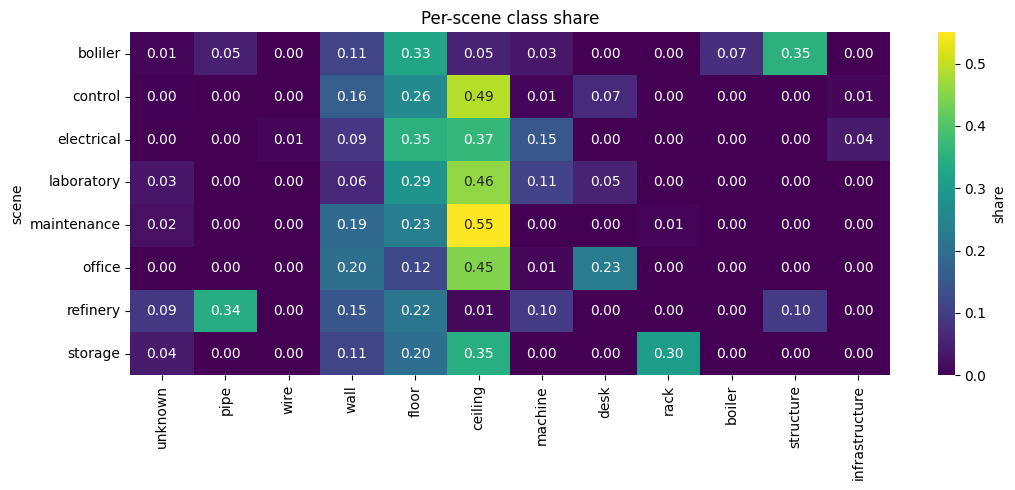


Saved:
  /content/drive/MyDrive/IS_project/splits/split.json
  /content/drive/MyDrive/IS_project/configs/class_remap.json
  /content/drive/MyDrive/IS_project/figures/class_distribution_full.png
  /content/drive/MyDrive/IS_project/figures/scene_class_heatmap.png


In [ ]:
import matplotlib.pyplot as plt

ACTIVE_IDS = [c for c in range(NUM_CLASSES) if global_counts.get(c, 0) > 0]
N_ACTIVE = len(ACTIVE_IDS)
OLD2NEW = {old: new for new, old in enumerate(ACTIVE_IDS)}
NEW2OLD = {new: old for old, new in OLD2NEW.items()}
NEW2NAME = {new: CLASS_NAMES[old] for new, old in NEW2OLD.items()}

print(f"Active classes: {N_ACTIVE}")
for new, old in NEW2OLD.items():
    cnt = global_counts[old]
    print(f"  new={new:2d}  old={old:2d}  {CLASS_NAMES[old]:14s}  {cnt:>12,}  ({100*cnt/total:.3f}%)")

counts_active = np.array([global_counts[NEW2OLD[i]] for i in range(N_ACTIVE)], dtype=np.float64)
freq = counts_active / counts_active.sum()
class_weights = 1.0 / np.log(1.02 + freq)
class_weights = class_weights / class_weights.mean()
print("\nClass weights (mean=1):")
for i, w in enumerate(class_weights):
    print(f"  {NEW2NAME[i]:14s}  {w:.3f}")

TRAIN_SCENES = ['boliler', 'laboratory', 'office', 'refinery', 'storage']
VAL_SCENES   = ['control']
TEST_SCENES  = ['electrical', 'maintenance']

split_map = {'train': [], 'val': [], 'test': []}
for m in file_meta:
    if m['scene'] in TRAIN_SCENES: split_map['train'].append(m['cache'])
    elif m['scene'] in VAL_SCENES: split_map['val'].append(m['cache'])
    elif m['scene'] in TEST_SCENES: split_map['test'].append(m['cache'])

print("\nSplit sizes:")
for k, v in split_map.items():
    print(f"  {k}: {len(v)} files")

with open(PROJECT_ROOT / 'splits' / 'split.json', 'w') as f:
    json.dump({
        'train_scenes': TRAIN_SCENES,
        'val_scenes': VAL_SCENES,
        'test_scenes': TEST_SCENES,
        'train': split_map['train'],
        'val': split_map['val'],
        'test': split_map['test'],
    }, f, indent=2)

with open(PROJECT_ROOT / 'configs' / 'class_remap.json', 'w') as f:
    json.dump({
        'active_old_ids': ACTIVE_IDS,
        'new2old': {str(k): v for k, v in NEW2OLD.items()},
        'new2name': {str(k): v for k, v in NEW2NAME.items()},
        'class_weights': class_weights.tolist(),
    }, f, indent=2, ensure_ascii=False)

FIG = PROJECT_ROOT / 'figures'
d = df_full[df_full['points']>0].sort_values('points', ascending=False)
plt.figure(figsize=(11,4.5))
plt.bar(d['class_name'], d['points'])
plt.yscale('log')
plt.xticks(rotation=40, ha='right')
plt.ylabel('points (log)')
plt.title('Full dataset: class distribution')
plt.tight_layout()
plt.savefig(FIG / 'class_distribution_full.png', dpi=140)
plt.show()

active_cols = [CLASS_NAMES[c] for c in ACTIVE_IDS if CLASS_NAMES[c] in df_scene.columns]
mat = df_scene.set_index('scene')[active_cols].astype(float)
mat_norm = mat.div(mat.sum(axis=1), axis=0)
plt.figure(figsize=(11,5))
import seaborn as sns
sns.heatmap(mat_norm, annot=True, fmt='.2f', cmap='viridis', cbar_kws={'label':'share'})
plt.title('Per-scene class share')
plt.tight_layout()
plt.savefig(FIG / 'scene_class_heatmap.png', dpi=140)
plt.show()

print("\nSaved:")
print(" ", PROJECT_ROOT / 'splits' / 'split.json')
print(" ", PROJECT_ROOT / 'configs' / 'class_remap.json')
print(" ", FIG / 'class_distribution_full.png')
print(" ", FIG / 'scene_class_heatmap.png')

## 5. Установка PyTorch Geometric

Сначала проверяем версию torch и наличие GPU, потом ставим torch-geometric, torch-scatter, torch-cluster под соответствующую CUDA.

In [ ]:
import torch
print(torch.__version__, torch.version.cuda)
print("GPU:", torch.cuda.get_device_name(0) if torch.cuda.is_available() else "NOT FOUND")

2.11.0+cu128 12.8
GPU: Tesla T4


In [ ]:
import torch
print(torch.__version__, torch.version.cuda)

!pip install -q torch-geometric
!pip install -q torch-scatter torch-cluster -f https://data.pyg.org/whl/torch-$(python -c "import torch; print(torch.__version__)")+cu121.html

2.11.0+cu128 12.8
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 108.0/108.0 kB 5.1 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 54.5/54.5 kB 5.6 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done


## 6. Эксперимент №1 — сплит по сценам

Первая попытка разделения: 5 целых сцен в train, 1 в val, 2 в test. Внутри готовится Dataset, PointNet++ и цикл обучения.

In [ ]:
import torch
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader
import numpy as np
import json
from pathlib import Path

PROJECT_ROOT = Path('/content/drive/MyDrive/IS_project')

with open(PROJECT_ROOT / 'configs' / 'class_remap.json') as f:
    remap_cfg = json.load(f)
with open(PROJECT_ROOT / 'splits' / 'split.json') as f:
    split_cfg = json.load(f)

OLD2NEW = {int(v): int(k) for k, v in remap_cfg['new2old'].items()}
N_CLASSES = len(remap_cfg['new2name'])
CLASS_WEIGHTS = torch.tensor(remap_cfg['class_weights'], dtype=torch.float32)

print(f"N_CLASSES={N_CLASSES}")
print(f"CLASS_WEIGHTS={CLASS_WEIGHTS.tolist()}")

N_POINTS = 16384

def load_npz(path):
    d = np.load(path)
    xyz = d['xyz'].astype(np.float32)
    lab = d['label'].astype(np.int32)
    return xyz, lab

def remap_labels(lab, old2new, n_classes):
    out = np.full_like(lab, -1)
    for old, new in old2new.items():
        out[lab == old] = new
    return out

def normalize_xyz(xyz):
    xyz = xyz - xyz.mean(axis=0)
    scale = np.abs(xyz).max()
    if scale > 0:
        xyz = xyz / scale
    return xyz

def augment(xyz):
    angle = np.random.uniform(0, 2 * np.pi)
    c, s = np.cos(angle), np.sin(angle)
    R = np.array([[c, -s, 0], [s, c, 0], [0, 0, 1]], dtype=np.float32)
    xyz = xyz @ R.T
    xyz += np.random.uniform(-0.05, 0.05, size=(1, 3)).astype(np.float32)
    xyz *= np.random.uniform(0.9, 1.1)
    xyz += np.random.normal(0, 0.005, size=xyz.shape).astype(np.float32)
    return xyz

class PointCloudDataset(Dataset):
    def __init__(self, file_list, n_points=N_POINTS, augment=False, old2new=OLD2NEW, n_classes=N_CLASSES):
        self.files = file_list
        self.n_points = n_points
        self.do_augment = augment
        self.old2new = old2new
        self.n_classes = n_classes

    def __len__(self):
        return len(self.files)

    def __getitem__(self, idx):
        xyz, lab = load_npz(self.files[idx])
        lab = remap_labels(lab, self.old2new, self.n_classes)

        valid = lab >= 0
        xyz, lab = xyz[valid], lab[valid]

        n = len(xyz)
        if n >= self.n_points:
            choice = np.random.choice(n, self.n_points, replace=False)
        else:
            choice = np.random.choice(n, self.n_points, replace=True)
        xyz, lab = xyz[choice], lab[choice]

        xyz = normalize_xyz(xyz)
        if self.do_augment:
            xyz = augment(xyz)

        return torch.from_numpy(xyz), torch.from_numpy(lab).long()

train_ds = PointCloudDataset(split_cfg['train'], augment=True)
val_ds   = PointCloudDataset(split_cfg['val'],   augment=False)
test_ds  = PointCloudDataset(split_cfg['test'],  augment=False)

print(f"Train: {len(train_ds)}  Val: {len(val_ds)}  Test: {len(test_ds)}")

xyz, lab = train_ds[0]
print(f"Sample — xyz: {xyz.shape} {xyz.dtype}, lab: {lab.shape}, unique: {lab.unique().tolist()}")

N_CLASSES=12
CLASS_WEIGHTS=[1.1909154653549194, 0.8014937043190002, 2.5210700035095215, 0.3801053762435913, 0.22363413870334625, 0.18077051639556885, 0.795666515827179, 0.7743274569511414, 0.7148311138153076, 1.6274356842041016, 0.5987870693206787, 2.19096302986145]
Train: 555  Val: 63  Test: 93
Sample — xyz: torch.Size([16384, 3]) torch.float32, lab: torch.Size([16384]), unique: [1, 3, 4, 5, 6]


In [ ]:
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch_geometric.nn import fps, radius, knn_interpolate
from torch_geometric.nn import PointNetConv, global_max_pool

class SetAbstraction(nn.Module):
    def __init__(self, ratio, r, in_channels, out_channels):
        super().__init__()
        self.ratio = ratio
        self.r = r
        self.conv = PointNetConv(
            nn.Sequential(
                nn.Linear(in_channels + 3, out_channels),
                nn.BatchNorm1d(out_channels),
                nn.ReLU(),
                nn.Linear(out_channels, out_channels),
                nn.BatchNorm1d(out_channels),
                nn.ReLU(),
            ), add_self_loops=False)

    def forward(self, x, pos, batch):
        idx = fps(pos, batch, ratio=self.ratio)
        row, col = radius(pos, pos[idx], self.r, batch, batch[idx], max_num_neighbors=64)
        edge_index = torch.stack([col, row], dim=0)
        x_dst = None if x is None else x[idx]
        x_out = self.conv((x, x_dst), (pos, pos[idx]), edge_index)
        return x_out, pos[idx], batch[idx]

class FeaturePropagation(nn.Module):
    def __init__(self, in_channels, skip_channels, out_channels):
        super().__init__()
        self.mlp = nn.Sequential(
            nn.Linear(in_channels + skip_channels, out_channels),
            nn.BatchNorm1d(out_channels),
            nn.ReLU(),
            nn.Linear(out_channels, out_channels),
            nn.BatchNorm1d(out_channels),
            nn.ReLU(),
        )

    def forward(self, x, pos, batch, x_skip, pos_skip, batch_skip):
        x_interp = knn_interpolate(x, pos, pos_skip, batch, batch_skip, k=3)
        x_cat = torch.cat([x_interp, x_skip], dim=1) if x_skip is not None else x_interp
        return self.mlp(x_cat)

class PointNetPP(nn.Module):
    def __init__(self, n_classes):
        super().__init__()
        self.sa1 = SetAbstraction(ratio=0.25, r=0.1, in_channels=0,  out_channels=64)
        self.sa2 = SetAbstraction(ratio=0.25, r=0.2, in_channels=64, out_channels=128)
        self.sa3 = SetAbstraction(ratio=0.25, r=0.4, in_channels=128,out_channels=256)

        self.fp3 = FeaturePropagation(256, 128, 256)
        self.fp2 = FeaturePropagation(256, 64,  128)
        self.fp1 = FeaturePropagation(128, 0,   128)

        self.head = nn.Sequential(
            nn.Linear(128, 128),
            nn.BatchNorm1d(128),
            nn.ReLU(),
            nn.Dropout(0.5),
            nn.Linear(128, n_classes),
        )

    def forward(self, pos, batch):
        x1, p1, b1 = self.sa1(None, pos, batch)
        x2, p2, b2 = self.sa2(x1,   p1,  b1)
        x3, p3, b3 = self.sa3(x2,   p2,  b2)

        x = self.fp3(x3, p3, b3, x2, p2, b2)
        x = self.fp2(x,  p2, b2, x1, p1, b1)
        x = self.fp1(x,  p1, b1, None, pos, batch)

        return self.head(x)

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
model = PointNetPP(n_classes=N_CLASSES).to(device)
total_params = sum(p.numel() for p in model.parameters())
print(f"Device: {device}")
print(f"Parameters: {total_params:,}")

pos_test = torch.randn(64, 3).to(device)
bat_test = torch.zeros(64, dtype=torch.long).to(device)
out_test = model(pos_test, bat_test)
print(f"Forward test: in={pos_test.shape} → out={out_test.shape}")

Device: cuda
Parameters: 406,348


ValueError: Expected more than 1 value per channel when training, got input size torch.Size([1, 256])

In [ ]:
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
model = PointNetPP(n_classes=N_CLASSES).to(device)
total_params = sum(p.numel() for p in model.parameters())
print(f"Device: {device}")
print(f"Parameters: {total_params:,}")

model.eval()
with torch.no_grad():
    pos_test = torch.randn(N_POINTS, 3).to(device)
    bat_test = torch.zeros(N_POINTS, dtype=torch.long).to(device)
    out_test = model(pos_test, bat_test)
print(f"Forward test: in={pos_test.shape} → out={out_test.shape}")
model.train()

Device: cuda
Parameters: 406,348
Forward test: in=torch.Size([16384, 3]) → out=torch.Size([16384, 12])


PointNetPP(
  (sa1): SetAbstraction(
    (conv): PointNetConv(local_nn=Sequential(
      (0): Linear(in_features=3, out_features=64, bias=True)
      (1): BatchNorm1d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (2): ReLU()
      (3): Linear(in_features=64, out_features=64, bias=True)
      (4): BatchNorm1d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (5): ReLU()
    ), global_nn=None)
  )
  (sa2): SetAbstraction(
    (conv): PointNetConv(local_nn=Sequential(
      (0): Linear(in_features=67, out_features=128, bias=True)
      (1): BatchNorm1d(128, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (2): ReLU()
      (3): Linear(in_features=128, out_features=128, bias=True)
      (4): BatchNorm1d(128, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (5): ReLU()
    ), global_nn=None)
  )
  (sa3): SetAbstraction(
    (conv): PointNetConv(local_nn=Sequential(
      (0): Linear(in_features=131

In [ ]:
from torch.utils.data import DataLoader
from torch_geometric.data import Data, Batch
import time, json
from pathlib import Path
from sklearn.metrics import confusion_matrix
import numpy as np
import shutil

BATCH_FILES = 4
NUM_WORKERS = 2
N_EPOCHS = 30
LR = 1e-3
SEED = 42

torch.manual_seed(SEED)
np.random.seed(SEED)

def collate_fn(batch):
    pos_list, lab_list, batch_idx = [], [], []
    for i, (xyz, lab) in enumerate(batch):
        pos_list.append(xyz)
        lab_list.append(lab)
        batch_idx.append(torch.full((len(xyz),), i, dtype=torch.long))
    return torch.cat(pos_list), torch.cat(lab_list), torch.cat(batch_idx)

train_loader = DataLoader(train_ds, batch_size=BATCH_FILES, shuffle=True,
                          num_workers=NUM_WORKERS, collate_fn=collate_fn, pin_memory=True)
val_loader   = DataLoader(val_ds,   batch_size=BATCH_FILES, shuffle=False,
                          num_workers=NUM_WORKERS, collate_fn=collate_fn, pin_memory=True)

class_weights_dev = CLASS_WEIGHTS.to(device)
criterion = nn.CrossEntropyLoss(weight=class_weights_dev, ignore_index=-1)
optimizer = torch.optim.Adam(model.parameters(), lr=LR, weight_decay=1e-4)
scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=N_EPOCHS, eta_min=1e-5)

CKPT_DIR = LOCAL_PROJECT / 'checkpoints'
LOG_PATH = LOCAL_PROJECT / 'logs' / 'train_log.json'

def compute_metrics(all_preds, all_labels, n_classes):
    all_preds  = np.concatenate(all_preds)
    all_labels = np.concatenate(all_labels)
    mask = all_labels >= 0
    preds, labels = all_preds[mask], all_labels[mask]
    oa = (preds == labels).mean()
    iou_per_class = []
    for c in range(n_classes):
        tp = ((preds == c) & (labels == c)).sum()
        fp = ((preds == c) & (labels != c)).sum()
        fn = ((preds != c) & (labels == c)).sum()
        if tp + fp + fn == 0:
            iou_per_class.append(float('nan'))
        else:
            iou_per_class.append(tp / (tp + fp + fn))
    miou = np.nanmean(iou_per_class)
    return {'oa': float(oa), 'miou': float(miou), 'iou_per_class': iou_per_class}

def run_epoch(loader, train=True):
    model.train() if train else model.eval()
    total_loss, all_preds, all_labels = 0, [], []
    ctx = torch.enable_grad() if train else torch.no_grad()
    with ctx:
        for pos, lab, bat in loader:
            pos, lab, bat = pos.to(device), lab.to(device), bat.to(device)
            if train:
                optimizer.zero_grad()
            logits = model(pos, bat)
            loss = criterion(logits, lab)
            if train:
                loss.backward()
                optimizer.step()
            total_loss += loss.item()
            preds = logits.argmax(dim=1).cpu().numpy()
            all_preds.append(preds)
            all_labels.append(lab.cpu().numpy())
    metrics = compute_metrics(all_preds, all_labels, N_CLASSES)
    metrics['loss'] = total_loss / len(loader)
    return metrics

best_miou = 0
log = []
print(f"Training for {N_EPOCHS} epochs, {len(train_loader)} batches/epoch")
print(f"{'Ep':>3} {'TrainLoss':>10} {'TrainOA':>8} {'TrainmIoU':>10} {'ValLoss':>9} {'ValOA':>7} {'ValmIoU':>9} {'Time':>6}")

for epoch in range(1, N_EPOCHS + 1):
    t0 = time.time()
    tr = run_epoch(train_loader, train=True)
    vl = run_epoch(val_loader,   train=False)
    scheduler.step()
    elapsed = time.time() - t0

    print(f"{epoch:>3}  {tr['loss']:>10.4f}  {tr['oa']:>8.4f}  {tr['miou']:>10.4f}  "
          f"{vl['loss']:>9.4f}  {vl['oa']:>7.4f}  {vl['miou']:>9.4f}  {elapsed:>5.0f}s")

    entry = {'epoch': epoch, 'train': tr, 'val': vl, 'lr': scheduler.get_last_lr()[0]}
    log.append(entry)
    with open(LOG_PATH, 'w') as f:
        json.dump(log, f, indent=2)

    if vl['miou'] > best_miou:
        best_miou = vl['miou']
        torch.save({'epoch': epoch, 'model_state': model.state_dict(),
                    'optimizer_state': optimizer.state_dict(),
                    'val_miou': best_miou, 'config': remap_cfg},
                   CKPT_DIR / 'best_model.pth')
        print(f"    ✓ Saved best model (val mIoU={best_miou:.4f})")

print(f"\nDone. Best val mIoU: {best_miou:.4f}")

from google.colab import files
files.download(str(CKPT_DIR / 'best_model.pth'))
print("Checkpoint downloaded to your computer.")

Training for 30 epochs, 139 batches/epoch
 Ep  TrainLoss  TrainOA  TrainmIoU   ValLoss   ValOA   ValmIoU   Time
  1      0.7709    0.8011      0.4754     2.2235   0.6921     0.1558     56s
    ✓ Saved best model (val mIoU=0.1558)
  2      0.8216    0.7864      0.4566     1.9389   0.7911     0.1949     56s
    ✓ Saved best model (val mIoU=0.1949)
  3      0.8177    0.7850      0.4514     1.9255   0.7953     0.1940     56s
  4      0.7168    0.8140      0.4883     1.9892   0.7725     0.1838     57s
  5      0.6711    0.8243      0.5004     2.3530   0.6880     0.1503     57s
  6      0.7115    0.8150      0.4891     2.0881   0.7455     0.1746     56s
  7      0.6390    0.8311      0.5090     2.4985   0.6300     0.1444     56s
  8      0.6118    0.8373      0.5182     2.3019   0.7481     0.1795     56s
  9      0.5844    0.8439      0.5257     2.2611   0.6546     0.1455     55s
 10      0.5734    0.8525      0.5382     2.6038   0.6031     0.1430     56s
 11      0.5679    0.8431      0.528

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

Checkpoint downloaded to your computer.


## 7. Получились плозие результаты, анализируем ошибки

После 30 эпох val mIoU достиг только 0.20, а val loss рос (с 1.8 до 2.6) пока train loss падал (с 0.77 до 0.40). Это overfitting в сочетании с неспособностью модели обобщить на новые сцены — слишком разная геометрия между, например, refinery (трубы) и office (столы).

## 8. Попытка №2 — те же сцены, больше точек на семпл

Перед сменой стратегии сплита была попытка увеличить плотность семплирования (32 768 точек вместо 16 384) и расширить радиусы SA-слоёв. Не помогло — проблема была не в архитектуре, а в сплите.

In [ ]:
N_POINTS_NEW = 32768

train_ds2 = PointCloudDataset(split_cfg['train'], n_points=N_POINTS_NEW, augment=True)
val_ds2   = PointCloudDataset(split_cfg['val'],   n_points=N_POINTS_NEW, augment=False)

train_loader2 = DataLoader(train_ds2, batch_size=2, shuffle=True,
                           num_workers=2, collate_fn=collate_fn, pin_memory=True)
val_loader2   = DataLoader(val_ds2,   batch_size=2, shuffle=False,
                           num_workers=2, collate_fn=collate_fn, pin_memory=True)

class SetAbstraction2(nn.Module):
    def __init__(self, ratio, r, in_channels, out_channels):
        super().__init__()
        self.ratio = ratio
        self.r = r
        self.conv = PointNetConv(
            nn.Sequential(
                nn.Linear(in_channels + 3, out_channels),
                nn.BatchNorm1d(out_channels),
                nn.ReLU(),
                nn.Linear(out_channels, out_channels),
                nn.BatchNorm1d(out_channels),
                nn.ReLU(),
            ), add_self_loops=False)

    def forward(self, x, pos, batch):
        idx = fps(pos, batch, ratio=self.ratio)
        row, col = radius(pos, pos[idx], self.r, batch, batch[idx], max_num_neighbors=64)
        edge_index = torch.stack([col, row], dim=0)
        x_dst = None if x is None else x[idx]
        x_out = self.conv((x, x_dst), (pos, pos[idx]), edge_index)
        return x_out, pos[idx], batch[idx]

class PointNetPP2(nn.Module):
    def __init__(self, n_classes):
        super().__init__()
        self.sa1 = SetAbstraction2(ratio=0.25, r=0.2,  in_channels=0,   out_channels=64)
        self.sa2 = SetAbstraction2(ratio=0.25, r=0.4,  in_channels=64,  out_channels=128)
        self.sa3 = SetAbstraction2(ratio=0.25, r=0.8,  in_channels=128, out_channels=256)
        self.fp3 = FeaturePropagation(256, 128, 256)
        self.fp2 = FeaturePropagation(256, 64,  128)
        self.fp1 = FeaturePropagation(128, 0,   128)
        self.head = nn.Sequential(
            nn.Linear(128, 128), nn.BatchNorm1d(128), nn.ReLU(),
            nn.Dropout(0.3),
            nn.Linear(128, n_classes),
        )

    def forward(self, pos, batch):
        x1, p1, b1 = self.sa1(None, pos, batch)
        x2, p2, b2 = self.sa2(x1,   p1,  b1)
        x3, p3, b3 = self.sa3(x2,   p2,  b2)
        x = self.fp3(x3, p3, b3, x2, p2, b2)
        x = self.fp2(x,  p2, b2, x1, p1, b1)
        x = self.fp1(x,  p1, b1, None, pos, batch)
        return self.head(x)

model2 = PointNetPP2(n_classes=N_CLASSES).to(device)
model2.eval()
with torch.no_grad():
    p_ = torch.randn(N_POINTS_NEW, 3).to(device)
    b_ = torch.zeros(N_POINTS_NEW, dtype=torch.long).to(device)
    o_ = model2(p_, b_)
print(f"Model2 forward: {p_.shape} -> {o_.shape}")
print(f"Params: {sum(p.numel() for p in model2.parameters()):,}")
model2.train()

N_EPOCHS2 = 40
optimizer2 = torch.optim.Adam(model2.parameters(), lr=5e-4, weight_decay=1e-4)
scheduler2 = torch.optim.lr_scheduler.CosineAnnealingLR(optimizer2, T_max=N_EPOCHS2, eta_min=1e-5)
LOG_PATH2 = LOCAL_PROJECT / 'logs' / 'train_log2.json'
CKPT2 = LOCAL_PROJECT / 'checkpoints' / 'best_model2.pth'

best_miou2 = 0
log2 = []
print(f"\nTraining model2 for {N_EPOCHS2} epochs")
print(f"{'Ep':>3} {'TrainLoss':>10} {'TrainOA':>8} {'TrainmIoU':>10} {'ValLoss':>9} {'ValOA':>7} {'ValmIoU':>9} {'Time':>6}")

for epoch in range(1, N_EPOCHS2 + 1):
    t0 = time.time()

    model2.train()
    total_loss, all_preds, all_labels = 0, [], []
    for pos, lab, bat in train_loader2:
        pos, lab, bat = pos.to(device), lab.to(device), bat.to(device)
        optimizer2.zero_grad()
        logits = model2(pos, bat)
        loss = criterion(logits, lab)
        loss.backward()
        optimizer2.step()
        total_loss += loss.item()
        all_preds.append(logits.argmax(1).cpu().numpy())
        all_labels.append(lab.cpu().numpy())
    tr = compute_metrics(all_preds, all_labels, N_CLASSES)
    tr['loss'] = total_loss / len(train_loader2)

    model2.eval()
    total_loss, all_preds, all_labels = 0, [], []
    with torch.no_grad():
        for pos, lab, bat in val_loader2:
            pos, lab, bat = pos.to(device), lab.to(device), bat.to(device)
            logits = model2(pos, bat)
            total_loss += criterion(logits, lab).item()
            all_preds.append(logits.argmax(1).cpu().numpy())
            all_labels.append(lab.cpu().numpy())
    vl = compute_metrics(all_preds, all_labels, N_CLASSES)
    vl['loss'] = total_loss / len(val_loader2)

    scheduler2.step()
    elapsed = time.time() - t0
    print(f"{epoch:>3}  {tr['loss']:>10.4f}  {tr['oa']:>8.4f}  {tr['miou']:>10.4f}  "
          f"{vl['loss']:>9.4f}  {vl['oa']:>7.4f}  {vl['miou']:>9.4f}  {elapsed:>5.0f}s")

    log2.append({'epoch': epoch, 'train': tr, 'val': vl})
    with open(LOG_PATH2, 'w') as f:
        json.dump(log2, f, indent=2)

    if vl['miou'] > best_miou2:
        best_miou2 = vl['miou']
        torch.save({'epoch': epoch, 'model_state': model2.state_dict(),
                    'val_miou': best_miou2, 'config': remap_cfg}, CKPT2)
        print(f"    ✓ Saved best model2 (val mIoU={best_miou2:.4f})")

print(f"\nDone. Best val mIoU: {best_miou2:.4f}")

Model2 forward: torch.Size([32768, 3]) -> torch.Size([32768, 12])
Params: 406,348

Training model2 for 40 epochs
 Ep  TrainLoss  TrainOA  TrainmIoU   ValLoss   ValOA   ValmIoU   Time
  1      1.7208    0.5399      0.2213     2.6439   0.2741     0.0528    221s
    ✓ Saved best model2 (val mIoU=0.0528)
  2      1.3143    0.6599      0.3209     2.7607   0.4969     0.1164    221s
    ✓ Saved best model2 (val mIoU=0.1164)
  3      1.1606    0.7047      0.3617     2.7394   0.5298     0.1004    222s
  4      1.0620    0.7333      0.3870     2.5442   0.5279     0.1125    221s
  5      1.0082    0.7533      0.4083     2.7384   0.6249     0.1462    221s
    ✓ Saved best model2 (val mIoU=0.1462)
  6      0.9306    0.7666      0.4231     3.7399   0.5464     0.1178    221s
  7      0.9173    0.7715      0.4261     2.4807   0.6762     0.1533    222s
    ✓ Saved best model2 (val mIoU=0.1533)
  8      0.8732    0.7820      0.4412     3.0420   0.5658     0.1294    221s
  9      0.8561    0.7828      0.

KeyboardInterrupt: 

## 9. Разбор структуры данных и переход к сплиту по circles

Просмотр структуры папок одной сцены показал, что внутри каждой сцены есть подпапки `circles1..circles5` — это разные проходы сканера. Решено пересоставить сплит: первые проходы → train, последние два прохода → val/test, без смешивания проходов между выборками.

In [ ]:
from pathlib import Path
DATA_ROOT = Path('/content/drive/MyDrive/IS')
scene = DATA_ROOT / 'boliler'
for p in sorted(scene.rglob('*'))[:50]:
    print(p.relative_to(scene))

circles1
circles1/scan_circle_0001_factory_room_1_lidar_station_1.ply
circles1/scan_circle_0002_factory_room_1_lidar_station_2.ply
circles1/scan_circle_0003_factory_room_1_lidar_station_3.ply
circles1/scan_circle_0004_factory_room_1_lidar_station_4.ply
circles1/scan_circle_0005_factory_room_1_lidar_station_5.ply
circles1/scan_circle_0006_factory_room_1_lidar_station_6.ply
circles1/scan_circle_0007_factory_room_1_lidar_station_7.ply
circles1/scan_circle_0008_factory_room_1_lidar_station_8.ply
circles1/scan_circle_0009_factory_room_1_lidar_station_9.ply
circles1/scan_circle_0010_factory_room_1_lidar_station_10.ply
circles1/scan_circle_0011_factory_room_1_lidar_station_11.ply
circles1/scan_circle_0012_factory_room_1_lidar_station_12.ply
circles1/scan_circle_0013_factory_room_1_lidar_station_13.ply
circles1/scan_circle_0014_factory_room_1_lidar_station_14.ply
circles1/scan_circle_0015_factory_room_1_lidar_station_15.ply
circles1/scan_circle_0016_factory_room_1_lidar_station_16.ply
circles1

In [ ]:
import json, glob
from pathlib import Path
from collections import defaultdict

DATA_ROOT    = Path('/content/drive/MyDrive/IS')
PROJECT_ROOT = Path('/content/drive/MyDrive/IS_project')
CACHE_ROOT   = PROJECT_ROOT / 'cache_npz'

all_npz = sorted(CACHE_ROOT.rglob('*.npz'))

train_files, val_files, test_files = [], [], []

scene_circle = defaultdict(lambda: defaultdict(list))
for p in all_npz:
    parts = p.relative_to(CACHE_ROOT).parts
    scene, circle = parts[0], parts[1]
    scene_circle[scene][circle].append(str(p))

print("Scene → circles:")
for scene, circles in sorted(scene_circle.items()):
    for circle, files in sorted(circles.items()):
        print(f"  {scene}/{circle}: {len(files)} files")

for scene, circles in sorted(scene_circle.items()):
    sorted_circles = sorted(circles.keys())
    for i, circle in enumerate(sorted_circles):
        files = sorted(circles[circle])
        if i == 0:
            n = len(files)
            train_files += files[:int(n*0.7)]
            val_files   += files[int(n*0.7):int(n*0.85)]
            test_files  += files[int(n*0.85):]
        else:
            test_files += files

print(f"\nNew split:")
print(f"  train: {len(train_files)}")
print(f"  val:   {len(val_files)}")
print(f"  test:  {len(test_files)}")

with open(PROJECT_ROOT / 'splits' / 'split_v2.json', 'w') as f:
    json.dump({'train': train_files, 'val': val_files, 'test': test_files}, f, indent=2)
print("Saved split_v2.json")

Scene → circles:
  boliler/circles1: 26 files
  boliler/circles2: 23 files
  boliler/circles3: 28 files
  boliler/circles4: 24 files
  boliler/circles5: 20 files
  control/circles1: 10 files
  control/circles2: 14 files
  control/circles3: 11 files
  control/circles4: 15 files
  control/circles5: 13 files
  electrical/circles1: 15 files
  electrical/circles2: 12 files
  electrical/circles3: 11 files
  electrical/circles4: 11 files
  electrical/circles5: 11 files
  laboratory/circles1: 24 files
  laboratory/circles2: 19 files
  laboratory/circles3: 22 files
  laboratory/circles4: 19 files
  laboratory/circles5: 25 files
  maintenance/circles1: 7 files
  maintenance/circles2: 4 files
  maintenance/circles3: 12 files
  maintenance/circles4: 4 files
  maintenance/circles5: 6 files
  office/circles1: 29 files
  office/circles2: 19 files
  office/circles3: 19 files
  office/circles4: 31 files
  office/circles5: 13 files
  refinery/circles1: 14 files
  refinery/circles2: 16 files
  refinery/c

OSError: [Errno 30] Read-only file system: '/content/drive/MyDrive/IS_project/splits/split_v2.json'

In [ ]:
import json
from pathlib import Path
from collections import defaultdict

LOCAL_PROJECT = Path('/content/local_project')
CACHE_ROOT    = Path('/content/drive/MyDrive/IS_project/cache_npz')

all_npz = sorted(CACHE_ROOT.rglob('*.npz'))

scene_circle = defaultdict(lambda: defaultdict(list))
for p in all_npz:
    parts = p.relative_to(CACHE_ROOT).parts
    scene, circle = parts[0], parts[1]
    scene_circle[scene][circle].append(str(p))

train_files, val_files, test_files = [], [], []

for scene, circles in sorted(scene_circle.items()):
    sorted_circles = sorted(circles.keys())
    n = len(sorted_circles)
    for i, circle in enumerate(sorted_circles):
        files = sorted(circles[circle])
        if i < n - 2:
            train_files += files
        elif i == n - 2:
            val_files += files
        else:
            test_files += files

print(f"Split by circle (last 2 circles per scene → val/test):")
print(f"  train: {len(train_files)} files")
print(f"  val:   {len(val_files)} files")
print(f"  test:  {len(test_files)} files")

split_path = LOCAL_PROJECT / 'splits' / 'split_v2.json'
split_path.parent.mkdir(parents=True, exist_ok=True)
with open(split_path, 'w') as f:
    json.dump({'train': train_files, 'val': val_files, 'test': test_files}, f, indent=2)
print("Saved:", split_path)

Split by circle (last 2 circles per scene → val/test):
  train: 419 files
  val:   160 files
  test:  132 files
Saved: /content/local_project/splits/split_v2.json


## 10. Эксперимент №2 — сплит по circles

419 / 160 / 132 файла. Все сцены представлены во всех частях, но проходы сканера не пересекаются. После этого val mIoU вырос с 0.20 до 0.47 без изменения архитектуры.

## 11. Финальное обучение, ошибки Colab и сохранение результатов

Дальнейшая работа продолжилась в `Lab3_final.ipynb`.  Также был один прогон, результаты потерялись при падении среды до сохранения чекпойнта на диск.


In [ ]:
import torch
import torch.nn as nn
import numpy as np
import json, time
from pathlib import Path
from torch.utils.data import DataLoader

LOCAL_PROJECT = Path('/content/local_project')

with open(LOCAL_PROJECT / 'splits' / 'split_v2.json') as f:
    split_v2 = json.load(f)

N_POINTS = 24576
BATCH_FILES = 2
N_EPOCHS = 40
SEED = 42
torch.manual_seed(SEED)
np.random.seed(SEED)

train_ds3 = PointCloudDataset(split_v2['train'], n_points=N_POINTS, augment=True)
val_ds3   = PointCloudDataset(split_v2['val'],   n_points=N_POINTS, augment=False)

train_loader3 = DataLoader(train_ds3, batch_size=BATCH_FILES, shuffle=True,
                           num_workers=2, collate_fn=collate_fn, pin_memory=True)
val_loader3   = DataLoader(val_ds3,   batch_size=BATCH_FILES, shuffle=False,
                           num_workers=2, collate_fn=collate_fn, pin_memory=True)

model3 = PointNetPP(n_classes=N_CLASSES).to(device)
optimizer3 = torch.optim.Adam(model3.parameters(), lr=1e-3, weight_decay=1e-4)
scheduler3 = torch.optim.lr_scheduler.CosineAnnealingLR(optimizer3, T_max=N_EPOCHS, eta_min=1e-5)

CKPT3    = LOCAL_PROJECT / 'checkpoints' / 'best_model_v2.pth'
LOG_PATH3 = LOCAL_PROJECT / 'logs' / 'train_log_v2.json'

best_miou3 = 0
log3 = []
print(f"Train: {len(train_ds3)}  Val: {len(val_ds3)}")
print(f"Batches/epoch: train={len(train_loader3)} val={len(val_loader3)}")
print(f"\n{'Ep':>3} {'TrLoss':>8} {'TrOA':>7} {'TrmIoU':>8} {'VaLoss':>8} {'VaOA':>7} {'VamIoU':>8} {'Time':>6}")

for epoch in range(1, N_EPOCHS + 1):
    t0 = time.time()

    model3.train()
    total_loss, all_preds, all_labels = 0, [], []
    for pos, lab, bat in train_loader3:
        pos, lab, bat = pos.to(device), lab.to(device), bat.to(device)
        optimizer3.zero_grad()
        logits = model3(pos, bat)
        loss = criterion(logits, lab)
        loss.backward()
        torch.nn.utils.clip_grad_norm_(model3.parameters(), 1.0)
        optimizer3.step()
        total_loss += loss.item()
        all_preds.append(logits.argmax(1).cpu().numpy())
        all_labels.append(lab.cpu().numpy())
    tr = compute_metrics(all_preds, all_labels, N_CLASSES)
    tr['loss'] = total_loss / len(train_loader3)

    model3.eval()
    total_loss, all_preds, all_labels = 0, [], []
    with torch.no_grad():
        for pos, lab, bat in val_loader3:
            pos, lab, bat = pos.to(device), lab.to(device), bat.to(device)
            logits = model3(pos, bat)
            total_loss += criterion(logits, lab).item()
            all_preds.append(logits.argmax(1).cpu().numpy())
            all_labels.append(lab.cpu().numpy())
    vl = compute_metrics(all_preds, all_labels, N_CLASSES)
    vl['loss'] = total_loss / len(val_loader3)

    scheduler3.step()
    elapsed = time.time() - t0
    print(f"{epoch:>3}  {tr['loss']:>8.4f}  {tr['oa']:>7.4f}  {tr['miou']:>8.4f}  "
          f"{vl['loss']:>8.4f}  {vl['oa']:>7.4f}  {vl['miou']:>8.4f}  {elapsed:>5.0f}s")

    log3.append({'epoch': epoch, 'train': tr, 'val': vl, 'lr': scheduler3.get_last_lr()[0]})
    with open(LOG_PATH3, 'w') as f:
        json.dump(log3, f, indent=2)

    if vl['miou'] > best_miou3:
        best_miou3 = vl['miou']
        torch.save({'epoch': epoch, 'model_state': model3.state_dict(),
                    'optimizer_state': optimizer3.state_dict(),
                    'val_miou': best_miou3, 'config': remap_cfg}, CKPT3)
        print(f"    ✓ best (val mIoU={best_miou3:.4f})")

print(f"\nDone. Best val mIoU: {best_miou3:.4f}")

Train: 419  Val: 160
Batches/epoch: train=210 val=80

 Ep   TrLoss    TrOA   TrmIoU   VaLoss    VaOA   VamIoU   Time
  1    1.7617   0.5706    0.2141    1.6758   0.6130    0.2239    131s
    ✓ best (val mIoU=0.2239)
  2    1.3635   0.7046    0.3243    1.2589   0.6937    0.3081    125s
    ✓ best (val mIoU=0.3081)
  3    1.2385   0.7371    0.3598    1.3784   0.7110    0.2960    125s
  4    1.1226   0.7611    0.3884    1.2058   0.7448    0.3398    126s
    ✓ best (val mIoU=0.3398)
  5    0.9663   0.7887    0.4280    1.3573   0.7234    0.3255    126s
  6    0.9077   0.8062    0.4507    1.2260   0.7524    0.3454    125s
    ✓ best (val mIoU=0.3454)
  7    0.8626   0.8120    0.4610    1.1391   0.7670    0.3818    125s
    ✓ best (val mIoU=0.3818)
  8    0.7947   0.8241    0.4799    1.0073   0.7518    0.3923    126s
    ✓ best (val mIoU=0.3923)
  9    0.7803   0.8289    0.4865    1.3135   0.7711    0.3742    126s
 10    0.7005   0.8432    0.5061    1.0417   0.8029    0.4164    125s
    ✓ bes